## Data Preprocessing and Augmentation

Before training the CNN model the CIFAR-10 dataset was preprocessed to make it more suitable for image classification. The first step involved scaling the pixel values from the original range of 0 to 255 to a normalized range between 0 and 1. This was done to improve training stability and allow the neural network to learn more effectively.

The class labels were then converted into one-hot encoded vectors. Since CIFAR-10 is a multi-class classification problem with ten possible categories one-hot encoding allows each class label to be represented in a format suitable for the output layer of the CNN.

To improve the model’s generalization ability and reduce overfitting data augmentation was applied to the training images. This involved generating slightly modified versions of the original images during training. The augmentation methods used were horizontal flipping, small rotations and small translations. These transformations were selected because they preserve the overall meaning of the images while helping the model become more robust to variations in object position and orientation.

This preprocessing and augmentation pipeline was chosen based on standard deep learning practice for image classification tasks and is appropriate for the CIFAR-10 dataset.


In [7]:
# Import required libraries
# TensorFlow is used to build and train the neural network
import tensorflow as tf

# Keras built-in dataset CIFAR-10
from tensorflow.keras.datasets import cifar10

# Used to convert class labels into one-hot encoded vectors
from tensorflow.keras.utils import to_categorical


# Load the CIFAR-10 dataset
# The dataset contains 60,000 images size 32x32 pixels

(X_train, y_train), (X_test, y_test) = cifar10.load_data()


# Normalize image pixel values
# Images originally contain pixel values from 0 to 255
# Neural networks perform better when input values are scaled
# Dividing by 255 converts pixel values into the range 0–1

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0


# Convert labels to one-hot encoding
# CIFAR-10 has 10 object classes
# One-hot encoding converts class numbers into binary vectors
# Example: class "3" becomes [0,0,0,1,0,0,0,0,0,0]

y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)


# Display dataset shapes to verify everything loaded correctly

print("Training images shape:", X_train.shape)
print("Training labels shape:", y_train.shape)

print("Test images shape:", X_test.shape)
print("Test labels shape:", y_test.shape)


c:\Users\killi\anaconda3\envs\ml\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000, 10)
Test images shape: (10000, 32, 32, 3)
Test labels shape: (10000, 10)


In [8]:
# Create a data augmentation pipeline
# Data augmentation increases the diversity of the training data by applying small random transformations to images.
# This helps reduce overfitting and improves model generalization.

data_augmentation = tf.keras.Sequential([

    # Randomly flip images horizontally
    # This helps the model recognise objects from mirrored viewpoints
    tf.keras.layers.RandomFlip("horizontal"),

    # Randomly rotate images slightly
    # This helps the model detect objects that are slightly tilted
    tf.keras.layers.RandomRotation(0.1),

    # Randomly shift images horizontally and vertically
    # This helps the model handle small positional changes
    tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1)

])

print("Data augmentation pipeline created successfully.")


Data augmentation pipeline created successfully.


## Visualizing Sample Images

Before training the CNN model visualise some examples from the CIFAR-10 dataset. This helps confirm that the images were loaded correctly and shows the types of objects the model will need to classify.

The CIFAR-10 dataset contains 10 different classes including airplanes, automobiles, birds, cats, deer, dogs, frogs, horses, ships and trucks. Displaying a small sample of images helps inspect the dataset and verify that the preprocessing steps have been applied correctly.


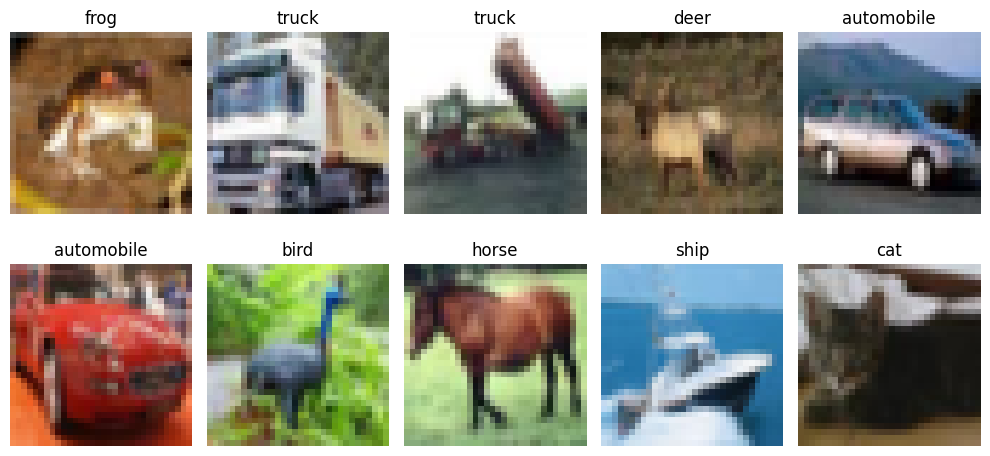

In [9]:
# Import libraries for visualization
import matplotlib.pyplot as plt
import numpy as np

# Define the class names for CIFAR-10
# These correspond to the numeric labels in the dataset
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Display the first 10 images from the training dataset
# This allows inspection of the dataset and confirmation that the images have loaded correctly

plt.figure(figsize=(10,5))

for i in range(10):
    
    # Create subplot grid
    plt.subplot(2,5,i+1)
    
    # Display image
    plt.imshow(X_train[i])
    
    # Show the class label for the image
    plt.title(class_names[np.argmax(y_train[i])])
    
    plt.axis("off")

# Adjust layout
plt.tight_layout()

# Display images
plt.show()


## Model Architecture

**Convolutional Neural Network (CNN)** was chosen to classify the CIFAR-10 images. A CNN is more suitable than a standard neural network for image classification because it can automatically learn important visual features such as edges, patterns and shapes directly from the input images.

The model architecture used is made of multiple convolutional and pooling layers followed by fully connected layers. The convolutional layers are used to extract visual features from the images while the pooling layers reduce the spatial dimensions of the feature maps and help lower computational complexity. After feature extraction the output is flattened and passed through dense layers for classification.

The architecture includes:

- An input layer for 32 × 32 colour images
- Three convolutional layers with ReLU activation
- Max-pooling layers to reduce feature map size
- A flatten layer to convert feature maps into a one-dimensional vector
- A dense hidden layer with dropout for regularization
- An output layer with 10 neurons and softmax activation for multi-class classification

This architecture was selected because it is simple, effective and appropriate for the CIFAR-10 dataset. It has good balance between model complexity and performance and reduces overfitting using dropout.


In [10]:
# Build the CNN model
# A Sequential model is used because the layers are stacked one after another in a simple linear order.

from tensorflow.keras import layers, models

model = models.Sequential()

# Input layer and first convolution block
# The input shape matches CIFAR-10 image dimensions: 32x32x3
# Conv2D applies 32 filters of size 3x3 to learn low-level features such as edges
# MaxPooling reduces the spatial size of the feature maps.

model.add(layers.Input(shape=(32, 32, 3)))
model.add(layers.Conv2D(32, (3, 3), activation="relu", padding="same"))
model.add(layers.MaxPooling2D((2, 2)))

# Second convolution block
# This layer increases the number of filters to 64 so the model can learn more complex patterns from the images.

model.add(layers.Conv2D(64, (3, 3), activation="relu", padding="same"))
model.add(layers.MaxPooling2D((2, 2)))

# Third convolution block
# This layer uses 128 filters to capture higher-level image features.

model.add(layers.Conv2D(128, (3, 3), activation="relu", padding="same"))
model.add(layers.MaxPooling2D((2, 2)))

# Flatten the feature maps
# The Flatten layer converts the 2D feature maps into a 1D vector so that the data can be passed into fully connected dense layers.

model.add(layers.Flatten())

# Fully connected layer
# A dense layer with 128 neurons is used to learn from the extracted features.
# ReLU is used as the activation function.
# Dropout is added to reduce overfitting by randomly disabling some neurons during training.

model.add(layers.Dense(128, activation="relu"))
model.add(layers.Dropout(0.5))

# Output layer
# The output layer has 10 neurons because CIFAR-10 has 10 classes.
# Softmax converts the outputs into probabilities for each class.

model.add(layers.Dense(10, activation="softmax"))

# Compile the model
# Adam is used as the optimizer because it performs well in practice.
# Categorical crossentropy is used because this is a multi-class problem.
# Accuracy is used as the main evaluation metric.

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Display the model architecture summary
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

## Training and Evaluation

After defining the CNN architecture the model was trained using the CIFAR-10 training dataset. The goal of training is to allow the neural network to learn meaningful features from the images and correctly classify them into one of the ten categories.

The model was trained using the **Adam optimizer** which is common in deep learning due to its efficiency and adaptive learning rate. The **categorical cross-entropy loss function** was used because the task is a multi-class classification problem with ten possible output classes.

- **Accuracy**: Measures the percentage of correctly classified images.
- **Loss**: Measures how well the model's predictions match the true labels.

Both training accuracy and validation accuracy were monitored during training to observe how well the model learns and to detect potential overfitting.

In [11]:
# Train the CNN model
# The model is trained using the training dataset.
# Use the test dataset as validation data to monitor performance during training.

history = model.fit(
    
    # Training data
    X_train, y_train,
    
    # Number of samples processed before updating weights
    batch_size=64,
    
    # Number of times the model sees the entire dataset
    epochs=10,
    
    # Validation data used to evaluate performance after each epoch
    validation_data=(X_test, y_test)
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 46s 52ms/step - accuracy: 0.3859 - loss: 1.6748 - val_accuracy: 0.5272 - val_loss: 1.3228
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.5516 - loss: 1.2629 - val_accuracy: 0.6186 - val_loss: 1.0835
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.6180 - loss: 1.0882 - val_accuracy: 0.6560 - val_loss: 0.9681
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.6599 - loss: 0.9806 - val_accuracy: 0.6817 - val_loss: 0.9222
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 42ms/step - accuracy: 0.6885 - loss: 0.8975 - val_accuracy: 0.7006 - val_loss: 0.8621
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.7107 - loss: 0.8313 - val_accuracy: 0.7282 - val_loss: 0.7987
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 55s 70ms/step - accuracy: 0.7291 - loss: 0.7830 - val_accuracy: 0.7306 - val_loss: 0.7862
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.7438 - loss: 0.7281 - 

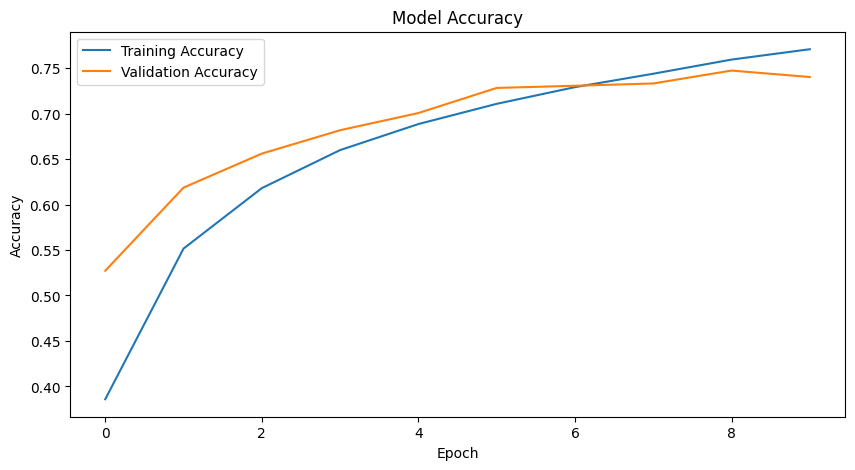

In [12]:
# Visualize training performance
# These graphs show how the model performed during training.

import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

## Model Performance Analysis

The graph shows the training and validation accuracy of the CNN model over 10 epochs.

The model starts with a relatively low training accuracy (around 40%) at the start while the validation accuracy is higher (approximately 55%). Training and validation accuracy steadily increase indicating that the model is successfully learning useful features from the dataset.

The training accuracy reaches approximately 78% while the validation accuracy reaches around 75%. This shows that the model performs well on both the training and unseen test data.

The gap between training accuracy and validation accuracy is small throughout training. This suggests that the model is not significantly overfitting and is able to generalize well to new data.

There is a slight fluctuation in validation accuracy around epochs 5–8 which may indicate minor instability or early signs of overfitting.

In conclusion the model has good learning behaviour and has a balance between training performance and generalization. Further improvements could be made by tuning hyperparameters or modifying the model architecture.

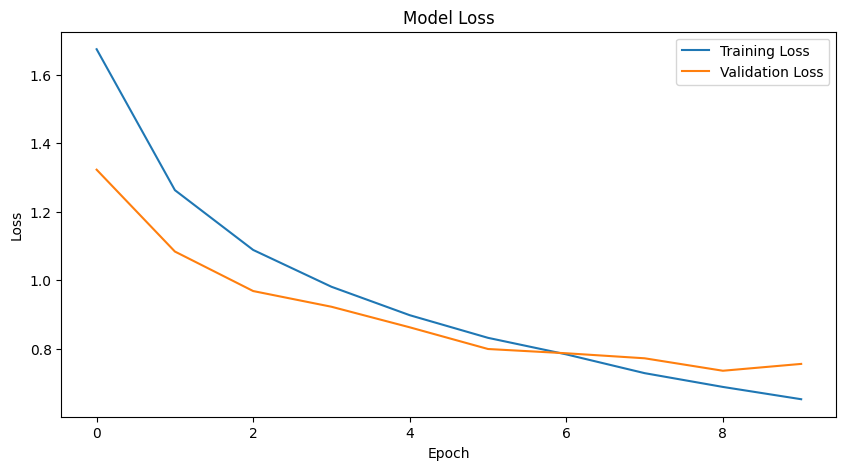

In [13]:
# Plot training and validation loss

plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Loss Analysis

The graph shows the training and validation loss of the CNN model over 10 epochs.

Training loss and validation loss are relatively high showing that the model has not learned meaningful features from the dataset. The loss for both training and validation steadily decreases showing that the model is improving and making more accurate predictions.

The training loss decreases consistently from approximately 1.6 to around 0.6 which shows that the model is learning effectively from the training data. The validation loss also decreases from around 1.25 to approximately 0.73 showing improved performance on unseen data.

There is a small fluctuation in validation loss around epochs 5–8 where the loss slightly increases before decreasing again. This may suggest minor overfitting or noise in the validation data but the overall there is a downward trend.

The gap between training loss and validation loss is relatively small which shows that the model is generalizing well and not overfitting significantly.

The decreasing loss values for both training and validation confirm that the model is learning effectively and improving its predictive performance over time.

## Model Improvement and Optimization

One improvement is **hyperparameter tuning**. Adjusting parameters such as the learning rate, batch size and number of epochs could lead to better model performance. Training the model for more epochs or using a smaller learning rate may allow the model to learn more detailed patterns.

Another improvement would be to **increase the depth of the network** by adding more convolutional layers. A deeper model can capture more complex features from the images which may improve classification accuracy.

**Regularization techniques** such as batch normalization or increasing dropout could also be applied to further reduce overfitting and improve generalization.

More advanced **data augmentation techniques** could be used to increase dataset diversity such as zooming or brightness adjustments.

**Transfer learning** could be applied by using pre-trained models such as VGG16 or ResNet. These models are trained on large datasets and can significantly improve performance when fine-tuned for CIFAR-10.

In [14]:
# Build an improved CNN model
# This version adds Batch Normalization to improve training stability and help the model learn more effectively.

from tensorflow.keras import layers, models

improved_model = models.Sequential()

# Input layer
improved_model.add(layers.Input(shape=(32, 32, 3)))

# First convolution block
improved_model.add(layers.Conv2D(32, (3, 3), padding="same", activation="relu"))
improved_model.add(layers.BatchNormalization())
improved_model.add(layers.MaxPooling2D((2, 2)))

# Second convolution block
improved_model.add(layers.Conv2D(64, (3, 3), padding="same", activation="relu"))
improved_model.add(layers.BatchNormalization())
improved_model.add(layers.MaxPooling2D((2, 2)))

# Third convolution block
improved_model.add(layers.Conv2D(128, (3, 3), padding="same", activation="relu"))
improved_model.add(layers.BatchNormalization())
improved_model.add(layers.MaxPooling2D((2, 2)))

# Flatten feature maps into a 1D vector
improved_model.add(layers.Flatten())

# Fully connected layer
improved_model.add(layers.Dense(128, activation="relu"))

# Dropout helps reduce overfitting
improved_model.add(layers.Dropout(0.5))

# Output layer for 10 CIFAR-10 classes
improved_model.add(layers.Dense(10, activation="softmax"))

# Compile the improved model
improved_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Show model summary
improved_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,706 (1.36 MB)

 Trainable params: 357,258 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [15]:
# Train the improved model with Early Stopping
# Early stopping helps prevent overfitting by stopping training when validation loss no longer improves.

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",          # watch validation loss
    patience=3,                  # stop after 3 epochs with no improvement
    restore_best_weights=True    # restore the best model weights
)


history_improved = improved_model.fit(
    X_train,
    y_train,
    batch_size=64,
    epochs=15,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 63s 76ms/step - accuracy: 0.4189 - loss: 1.6256 - val_accuracy: 0.5531 - val_loss: 1.2483
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 66s 84ms/step - accuracy: 0.5650 - loss: 1.2237 - val_accuracy: 0.6028 - val_loss: 1.1053
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 65s 83ms/step - accuracy: 0.6387 - loss: 1.0415 - val_accuracy: 0.6170 - val_loss: 1.1751
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 64s 81ms/step - accuracy: 0.6793 - loss: 0.9222 - val_accuracy: 0.6263 - val_loss: 1.0673
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 63s 81ms/step - accuracy: 0.7156 - loss: 0.8265 - val_accuracy: 0.7334 - val_loss: 0.7816
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 63s 81ms/step - accuracy: 0.7401 - loss: 0.7544 - val_accuracy: 0.7181 - val_loss: 0.8269
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 65s 83ms/step - accuracy: 0.7633 - loss: 0.6834 - val_accuracy: 0.7393 - val_loss: 0.7648
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 64s 81ms/step - accuracy: 0.7812 - loss: 0.6296 - 

In [16]:
# Evaluate the improved model on the test set

improved_loss, improved_acc = improved_model.evaluate(X_test, y_test)

print("Improved Model Test Loss:", improved_loss)
print("Improved Model Test Accuracy:", improved_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7623 - loss: 0.7132
Improved Model Test Loss: 0.713193416595459
Improved Model Test Accuracy: 0.7623000144958496


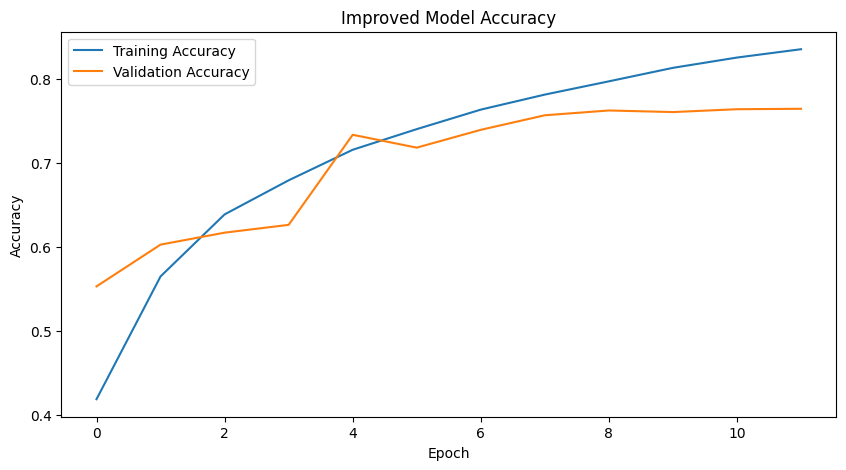

In [17]:
# Plot training and validation accuracy for the improved model

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history_improved.history["accuracy"], label="Training Accuracy")
plt.plot(history_improved.history["val_accuracy"], label="Validation Accuracy")
plt.title("Improved Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

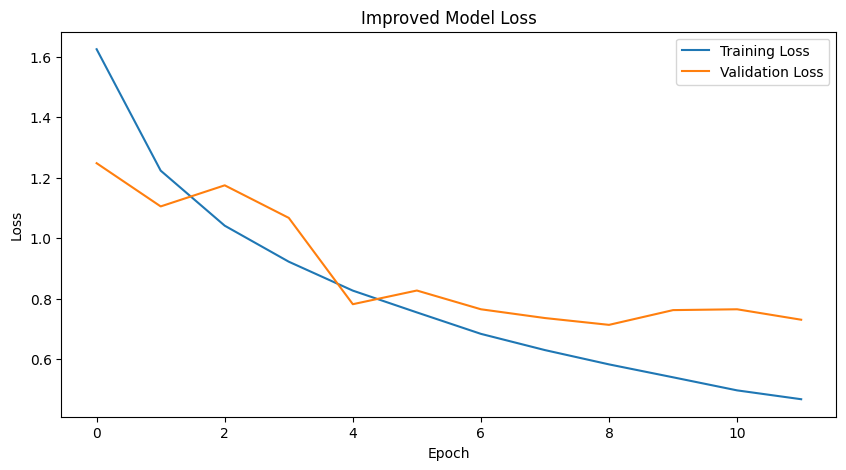

In [18]:
# Plot training and validation loss for the improved model

plt.figure(figsize=(10, 5))
plt.plot(history_improved.history["loss"], label="Training Loss")
plt.plot(history_improved.history["val_loss"], label="Validation Loss")
plt.title("Improved Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [19]:
# Compare the original and improved model test accuracy

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("Original Model Test Accuracy:", test_acc)
print("Improved Model Test Accuracy:", improved_acc)

Original Model Test Accuracy: 0.7401999831199646
Improved Model Test Accuracy: 0.7623000144958496
